5. Architecture Experiments

In the previous overfitting experiment, all the applied techniques didn't had an significiant impact on the basline architecture. This is likley the cause because of the architecture of the model itself. I assume the quantitiy of images is just to low and the model is to big, in order to learn anything it can just memorize it. In this notebook I want to rerun the experiements but with 2 changes to our CNNBuilder:
1. Data augementation
2. Global Average Pooling

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from data.dataset import Dataset
from data.rarity_classes import RARITY_CLASSES
from models.cnn_builder import CNNBuilder
from models.training_callbacks import default_callbacks
from evaluation.evaluation_metrics import EvaluationMetrics

import tensorflow as tf
import random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

/Users/markusgarmeister/Desktop/ML_PokeCard/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = Dataset()
X_train, X_val, X_test, y_train, y_val, y_test = dataset.get_train_val_test_split()

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Input shape: {X_train.shape[1:]}")
print(f"Number of classes: {y_train.shape[1]}")

Training set: 1750 samples
Validation set: 375 samples
Test set: 375 samples
Input shape: (168, 120, 3)
Number of classes: 5


5.1 Helper Function

In [3]:
def train_and_plot(builder, name, epochs=30):
    model = builder.build_model()
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=default_callbacks(),
        verbose=0,
    )
    print(f"{name}: val_loss={history.history['val_loss'][-1]}, val_acc={history.history['val_accuracy'][-1]}")
    return model, history

5.2 Experiemnts

In [ ]:
histories = {}
models = {}

# 1. Baseline — same architecture as notebook 4 baseline, for direct reference
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64],
    fully_connected_layers=[128],
)
models['Baseline'], histories['Baseline'] = train_and_plot(builder, 'Baseline')

# 2. Augmentation — adds RandomFlip / RandomRotation / RandomZoom / RandomBrightness
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64],
    fully_connected_layers=[128],
)
builder.apply_augmentation = True
models['Aug'], histories['Aug'] = train_and_plot(builder, 'Aug')

# 3. Global Average Pooling — replaces Flatten()->Dense(128) with GAP
#    Deeper convs [32,64,128] and a [128,64] head give GAP enough capacity to learn
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64, 128],
    fully_connected_layers=[128, 64],
)
builder.use_global_pooling = True
models['GAP'], histories['GAP'] = train_and_plot(builder, 'GAP')

# 4. Flatten + Dropout — keeps spatial info via Flatten but uses a smaller FC head
#    so Dropout(0.5) actually has bite
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64, 128],
    fully_connected_layers=[64],
)
builder.apply_dropout = True
models['Dropout'], histories['Dropout'] = train_and_plot(builder, 'Dropout')

# 5. All combined — augmentation + GAP + dropout + batchnorm + L2 stacked
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64],
    fully_connected_layers=[128],
)
builder.apply_augmentation = True
builder.use_global_pooling = True
builder.apply_dropout = True
builder.apply_batch_normalization = True
builder.apply_regularization = True
models['All Combined'], histories['All Combined'] = train_and_plot(builder,'All Combined')

2026-04-30 18:34:38.964483: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-30 18:34:38.964690: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-30 18:34:38.964716: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-30 18:34:38.964896: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-30 18:34:38.964918: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-30 18:34:40.770587: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Baseline: val_loss=1.0185036659240723, val_acc=0.6853333115577698
Aug: val_loss=1.4463447332382202, val_acc=0.3786666691303253
GAP: val_loss=1.0225600004196167, val_acc=0.5733333230018616
Dropout: val_loss=1.0993335247039795, val_acc=0.6853333115577698
All Combined: val_loss=1.6160532236099243, val_acc=0.2266666740179062


5.3 Train vs Validation Loss


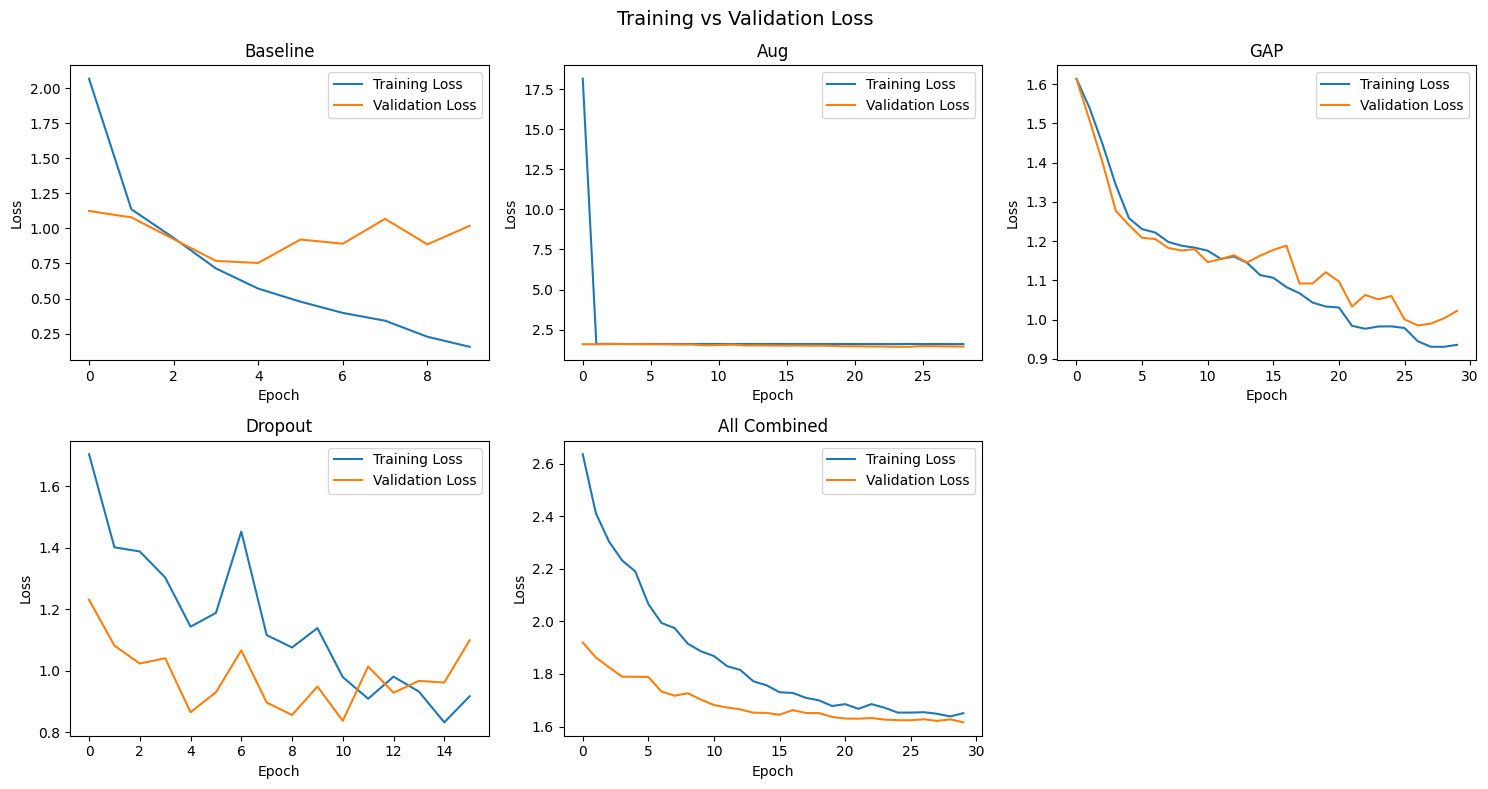

In [6]:
n = len(histories)
ncols = min(n, 3)
nrows = (n + ncols - 1) // ncols  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

for i, (name, history) in enumerate(histories.items()):
    axes[i].plot(history.history['loss'], label='Training Loss')
    axes[i].plot(history.history['val_loss'], label='Validation Loss')
    axes[i].set_title(name)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

# Hide any unused subplots
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Training vs Validation Loss', fontsize=14)
plt.tight_layout()
plt.show()


5.4 Validation Accuracy Comparison


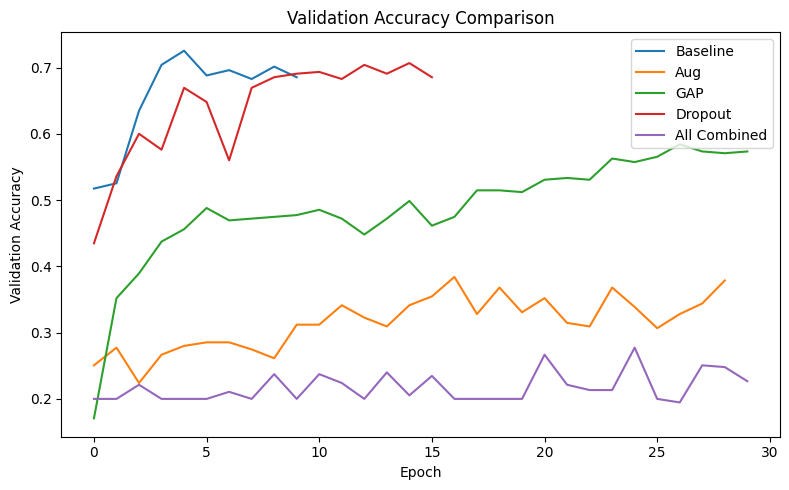

In [7]:
plt.figure(figsize=(8, 5))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

5.5 Evvaluation metrics



Best configuration by val_loss: Baseline
Test accuracy: 0.6773
Macro F1:      0.6759

              precision    recall  f1-score   support

      Common       0.58      0.81      0.68        75
    Uncommon       0.64      0.45      0.53        75
        Rare       0.56      0.65      0.60        75
  Ultra Rare       0.88      0.84      0.86        75
 Secret Rare       0.82      0.63      0.71        75

    accuracy                           0.68       375
   macro avg       0.70      0.68      0.68       375
weighted avg       0.70      0.68      0.68       375



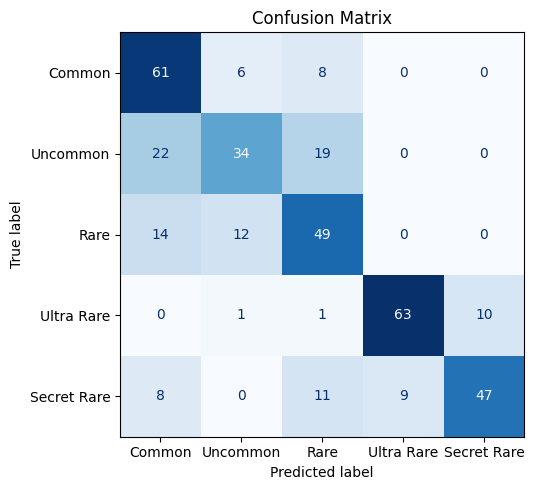

In [8]:
best_name = min(histories, key=lambda n: min(histories[n].history['val_loss']))
print(f"Best configuration by val_loss: {best_name}")

best_model = models[best_name]
y_pred_test = best_model.predict(X_test, verbose=0)

metrics = EvaluationMetrics(y_test, y_pred_test)
print(f"Test accuracy: {metrics.accuracy:.4f}")
print(f"Macro F1:      {metrics.f1_macro:.4f}\n")

metrics.print_classification_report(RARITY_CLASSES)
metrics.plot_confusion_matrix(RARITY_CLASSES)
                              
                

Test accuracy: 0.6773
Macro F1:      0.6759

              precision    recall  f1-score   support

      Common       0.58      0.81      0.68        75
    Uncommon       0.64      0.45      0.53        75
        Rare       0.56      0.65      0.60        75
  Ultra Rare       0.88      0.84      0.86        75
 Secret Rare       0.82      0.63      0.71        75

    accuracy                           0.68       375
   macro avg       0.70      0.68      0.68       375
weighted avg       0.70      0.68      0.68       375



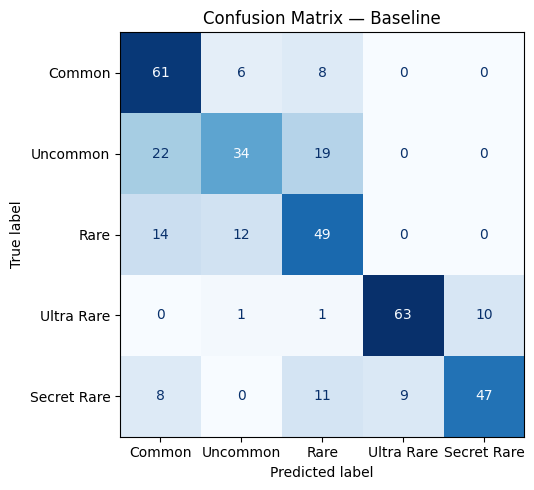

In [9]:
metrics = EvaluationMetrics(y_test, y_pred_test)
print(f"Test accuracy: {metrics.accuracy:.4f}")
print(f"Macro F1:      {metrics.f1_macro:.4f}\n")

metrics.print_classification_report(RARITY_CLASSES)
metrics.plot_confusion_matrix(RARITY_CLASSES, title=f"Confusion Matrix — {best_name}")